In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)

In [2]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(7043, 21)


In [4]:
print("Column Names:")
print(df.columns)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [5]:
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df=df.drop_duplicates()
print(df.shape)

(7043, 21)


In [9]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df["TotalCharges"].fillna(df["TotalCharges"].median())

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [12]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


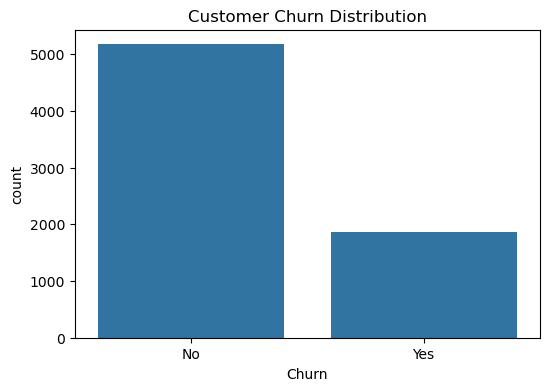

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn",data=df)
plt.title("Customer Churn Distribution")
plt.show()

### Observation

- The dataset contains both churned and retained customers.
- Retained customers are significantly higher than churned customers.
- This indicates class imbalance in the target variable.
- Customer retention appears stronger than customer loss.

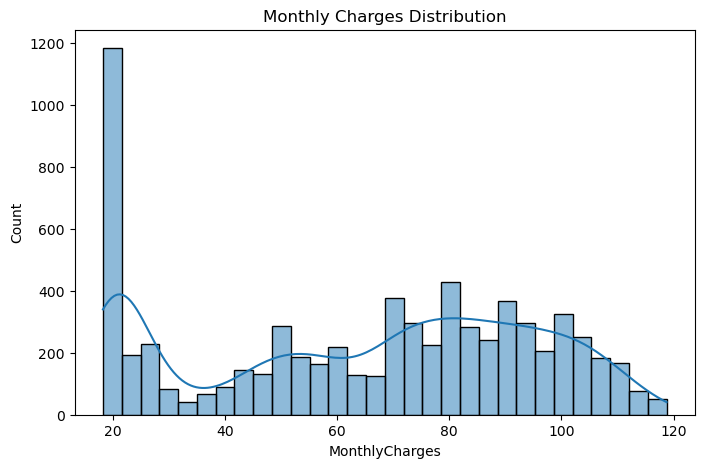

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"],bins=30,kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

## Observation

- Monthly charges vary considerably across customers.
- Most customers fall within the moderate monthly charge range.
- A smaller group of customers pay substantially higher monthly charges.
- Pricing differences may influence customer retention patterns.

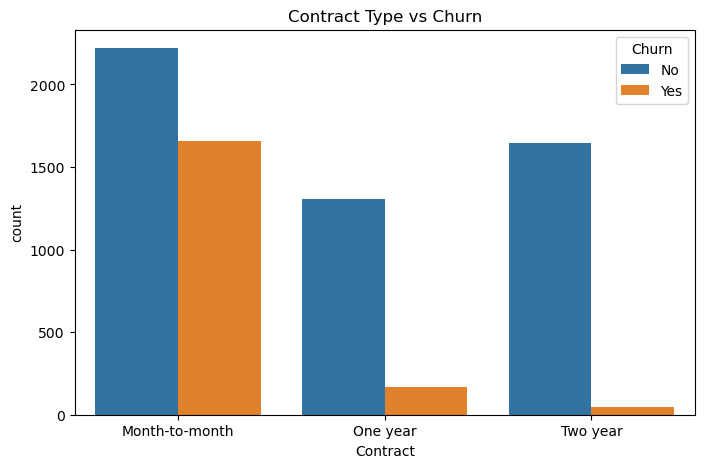

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Contract Type vs Churn")
plt.show()

## Observation

- Customers with Month-to-Month contracts exhibit the highest churn rate.
- Customers with One-Year and Two-Year contracts show lower churn rates.
- Longer contract commitments improve customer retention.
- Contract type appears to be a significant factor influencing customer churn.

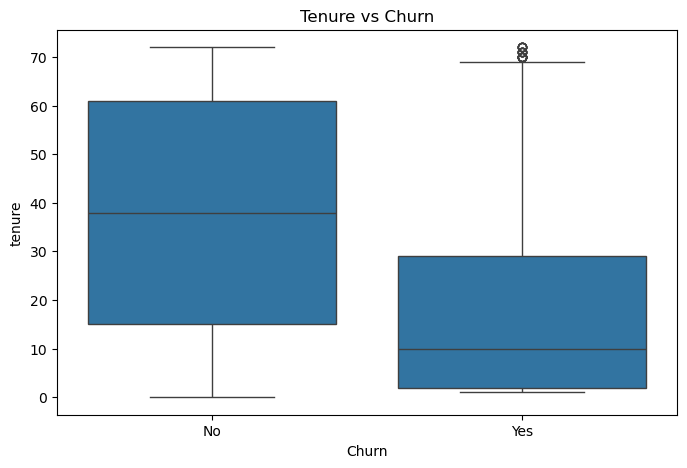

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Tenure vs Churn")
plt.show()

## Observation

- Customers who churn generally have lower tenure values.
- Long-term customers are more likely to remain with the company.
- Customer loyalty tends to increase with tenure.
- Tenure is a strong indicator of churn behavior.

In [18]:
numeric_df=df.select_dtypes(include=np.number)

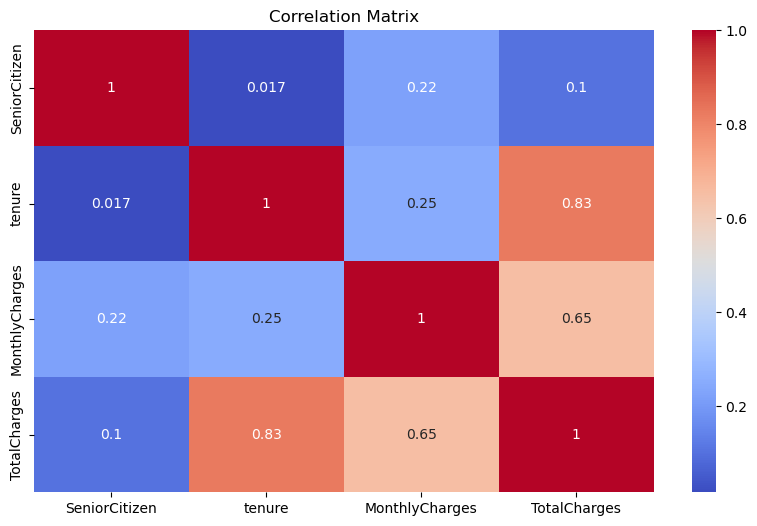

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Observation

- Tenure and TotalCharges show a strong positive correlation.
- Customers who remain longer contribute higher total revenue.
- MonthlyCharges have a moderate relationship with TotalCharges.
- No severe multicollinearity is observed among the numerical features.

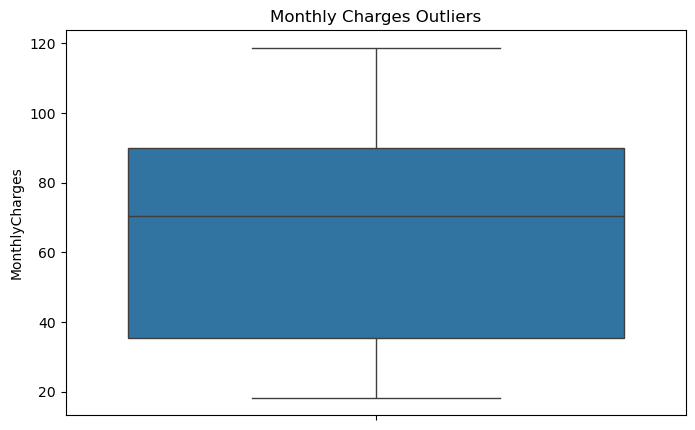

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["MonthlyCharges"])
plt.title("Monthly Charges Outliers")
plt.show()

## Observation

- A small number of customers have exceptionally high monthly charges compared to the majority of customers.
- These observations are considered outliers according to the boxplot analysis.
- The outliers may correspond to high-value customers using premium service plans.
- Since these values are realistic business observations, they should be retained for further analysis rather than removed.

## Observation

- Most churned customers have lower tenure values.
- Customers who stay longer are generally less likely to churn.
- This suggests that customer loyalty increases over time.

# Overall Findings

- The dataset was cleaned by handling missing values and converting data types.
- Most customers remain with the company, while a smaller group has churned.
- Month-to-Month contract customers show the highest churn rate.
- Customers with lower tenure are more likely to leave.
- Higher monthly charges appear to be associated with increased churn.
- Tenure and TotalCharges have a strong positive relationship.
- A few high-value customers have significantly higher monthly charges.

# Conclusion

The analysis suggests that contract type, tenure, and monthly charges are important factors affecting customer churn. These insights can be used in the next phase of the project to build a churn prediction model.

In [21]:
df.to_csv("Cleaned_Telco_Customer_Churn.csv", index=False)